# TASK 2: Quantitative Analysis with TA-Lib and PyNance

**Author:** Ruhama Beshada
**Branch:** task-2

## Description

* Load six stock CSV files.
* Compute technical indicators (SMA, RSI, MACD) with **TA-Lib**.
* Use **PyNance** for financial metrics.
* Visualize trends to analyze stock performance.


In [3]:
import talib
print(talib.__version__)

0.6.8


# Task 2: Stock Data Analysis Setup

Imports essential libraries for stock analysis:

* `pandas` and `numpy` for data handling
* `matplotlib` for plotting
* `TA-Lib` for technical indicators

Sets a clean plotting style with Seaborn.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib

plt.style.use("seaborn-v0_8")


# Load Stock Data

Reads all CSV files from the data folder into pandas DataFrames for analysis.


In [6]:
# 1. Import os
import os
import pandas as pd

# 2. Path to your data folder
DATA_FOLDER = "../data/stock_data"

# 3. Read all CSVs inside the folder
csv_files = [f for f in os.listdir(DATA_FOLDER) if f.endswith(".csv")]
print("CSV files found:", csv_files)

# 4. Load all CSVs into a dictionary of DataFrames
dfs = {}
for file in csv_files:
    file_path = os.path.join(DATA_FOLDER, file)
    dfs[file] = pd.read_csv(file_path)

# 5. Preview one of the CSVs
dfs[csv_files[0]].head()

CSV files found: ['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'MSFT.csv', 'NVDA.csv']


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


# Preview Stock Data

Displays the first few rows and basic info of each loaded CSV DataFrame.


In [7]:
for name, df in dfs.items():
    print(f"=== {name} ===")
    display(df.head())
    print(df.info())
    print("\n")

=== AAPL.csv ===


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB
None


=== AMZN.csv ===


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB
None


=== GOOG.csv ===


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2923 entries, 0 to 2922
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2923 non-null   object 
 1   Close   2923 non-null   float64
 2   High    2923 non-null   float64
 3   Low     2923 non-null   float64
 4   Open    2923 non-null   float64
 5   Volume  2923 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 137.1+ KB
None


=== MSFT.csv ===


,Date,Close,High,Low,Open,Volume
0,2009-01-02,14.872976,14.924187,14.170662,14.287715,50084000
1,2009-01-05,15.011971,15.121707,14.675444,14.777866,61475200
2,2009-01-06,15.187551,15.363130,15.077815,15.180236,58083400
3,2009-01-07,14.273087,14.843718,14.251139,14.770560,72709900
4,2009-01-08,14.719351,14.770561,14.302350,14.360876,70255400


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB
None


=== NVDA.csv ===


,Date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB
None




# Convert Date Column

Converts the 'Date' column in each DataFrame to datetime format for analysis.


In [8]:
for df in dfs.values():
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])

# List Loaded DataFrames

Prints the names of all loaded CSV files stored as DataFrames.


In [9]:
print(dfs.keys())

dict_keys(['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'MSFT.csv', 'NVDA.csv'])


# Prepare AAPL Stock Data

Selects the AAPL CSV, converts the 'Date' column to datetime, sorts by date, and sets it as the index.


In [10]:
df_stock = dfs['AAPL.csv']  # use the exact filename
df_stock['Date'] = pd.to_datetime(df_stock['Date'])  # ensure date is datetime
df_stock = df_stock.sort_values('Date')
df_stock.set_index('Date', inplace=True)
df_stock.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


# Process All Stock Data

Converts 'Date' to datetime, sorts by date, and sets it as index for all loaded stock DataFrames.


In [11]:

for name, df in dfs.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)
    df.set_index('Date', inplace=True)
    print(f"Processed {name}:")
    display(df.head())


Processed AAPL.csv:


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


Processed AMZN.csv:


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


Processed GOOG.csv:


...

,Close,High,Low,Open,Volume
Date,,,,,
2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


Processed MSFT.csv:


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,14.872976,14.924187,14.170662,14.287715,50084000
2009-01-05,15.011971,15.121707,14.675444,14.777866,61475200
2009-01-06,15.187551,15.363130,15.077815,15.180236,58083400
2009-01-07,14.273087,14.843718,14.251139,14.770560,72709900
2009-01-08,14.719351,14.770561,14.302350,14.360876,70255400


Processed NVDA.csv:


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


# Compute Simple Moving Averages

Calculates 20-day and 50-day SMA for the 'Close' price using TA-Lib.


In [12]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

# Compute Exponential Moving Averages

Calculates 20-day and 50-day EMA for the 'Close' price using TA-Lib.


In [13]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)
df['EMA_50'] = talib.EMA(df['Close'], timeperiod=50)

# Compute RSI

Calculates 14-day Relative Strength Index (RSI) for the 'Close' price using TA-Lib.


In [14]:
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

# Compute MACD

Calculates MACD, MACD signal, and MACD histogram for the 'Close' price using TA-Lib.


In [15]:

df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'])

# Compute ATR

Calculates 14-day Average True Range (ATR) using High, Low, and Close prices with TA-Lib.


In [16]:

df['ATR_14'] = talib.ATR(df['High'], df['Low'], df['Close'], timeperiod=14)

# Compute Technical Indicators

Calculates multiple TA-Lib indicators (SMA, EMA, RSI, MACD, Bollinger Bands, ATR) for all loaded stock DataFrames.


In [17]:

import talib

for name, df in dfs.items():
    df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
    df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)
    df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'])
    df['BB_upper'], df['BB_middle'], df['BB_lower'] = talib.BBANDS(df['Close'])
    df['ATR_14'] = talib.ATR(df['High'], df['Low'], df['Close'], timeperiod=14)
    print(f"Indicators calculated for {name}")

Indicators calculated for AAPL.csv
Indicators calculated for AMZN.csv
Indicators calculated for GOOG.csv
Indicators calculated for META.csv
Indicators calculated for MSFT.csv
Indicators calculated for NVDA.csv


# Plotting Setup

Imports Matplotlib and Seaborn, and sets a darkgrid style for visualizations.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

# Compute Simple Moving Averages

Calculates 20-day and 50-day SMA for the 'Close' price using TA-Lib.


In [20]:

import talib

df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

# Plot Close Price with SMAs

Plots the stock's Close price along with 20-day and 50-day SMA indicators using Matplotlib.


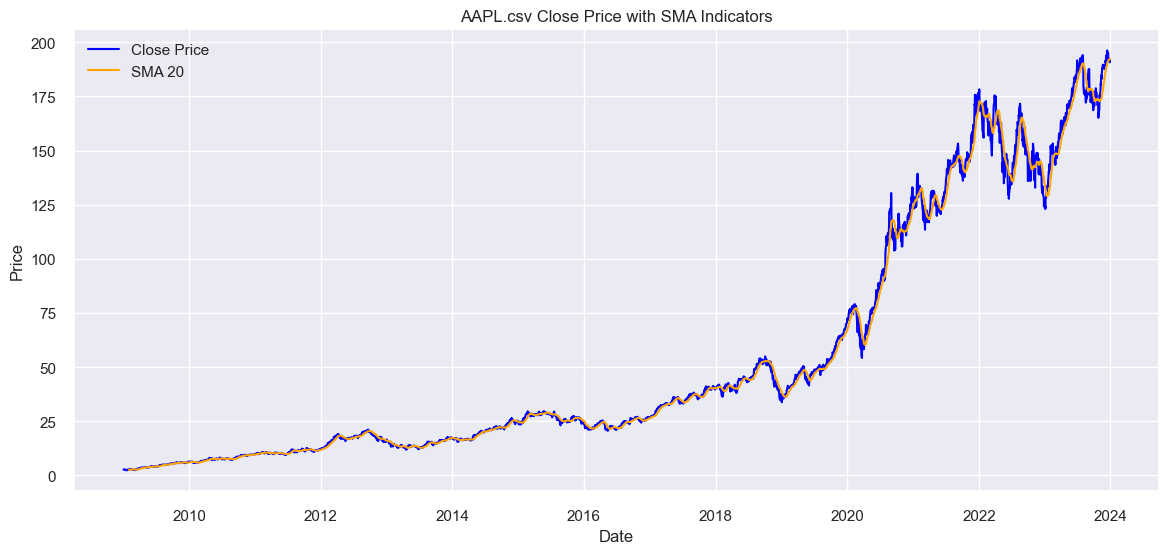

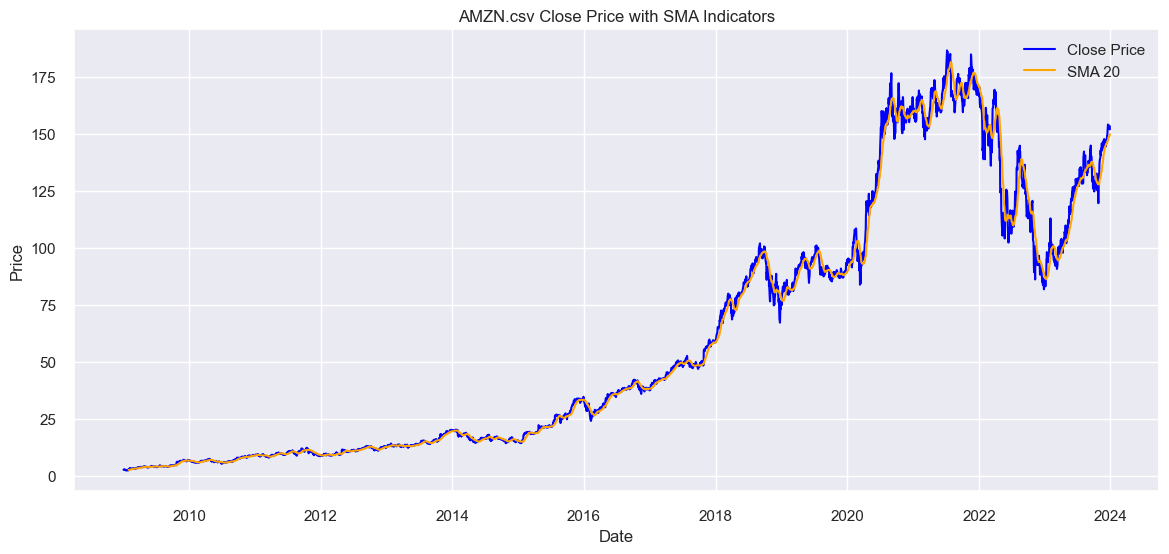

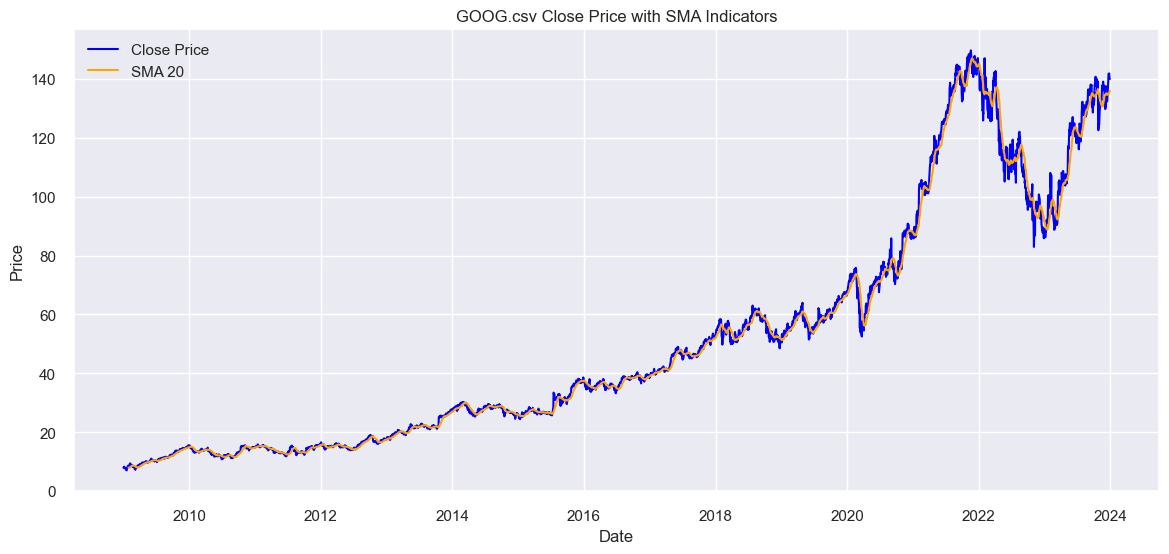

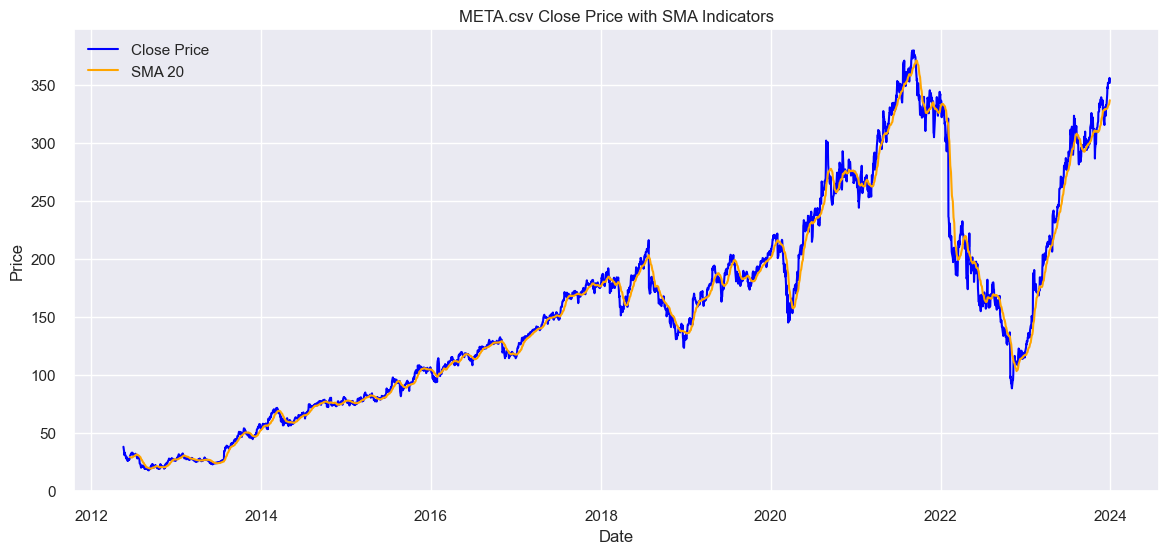

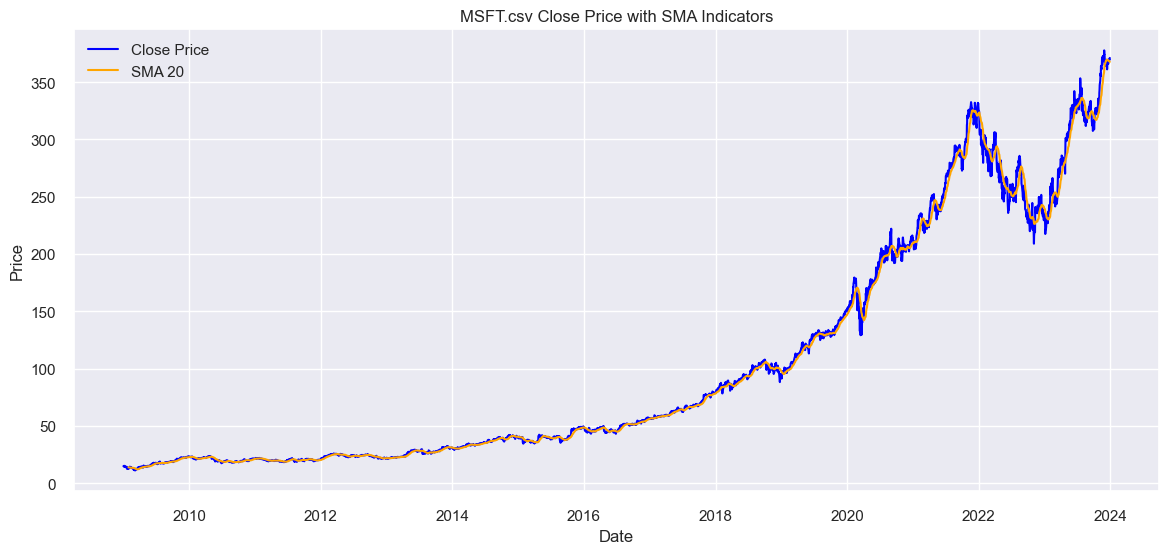

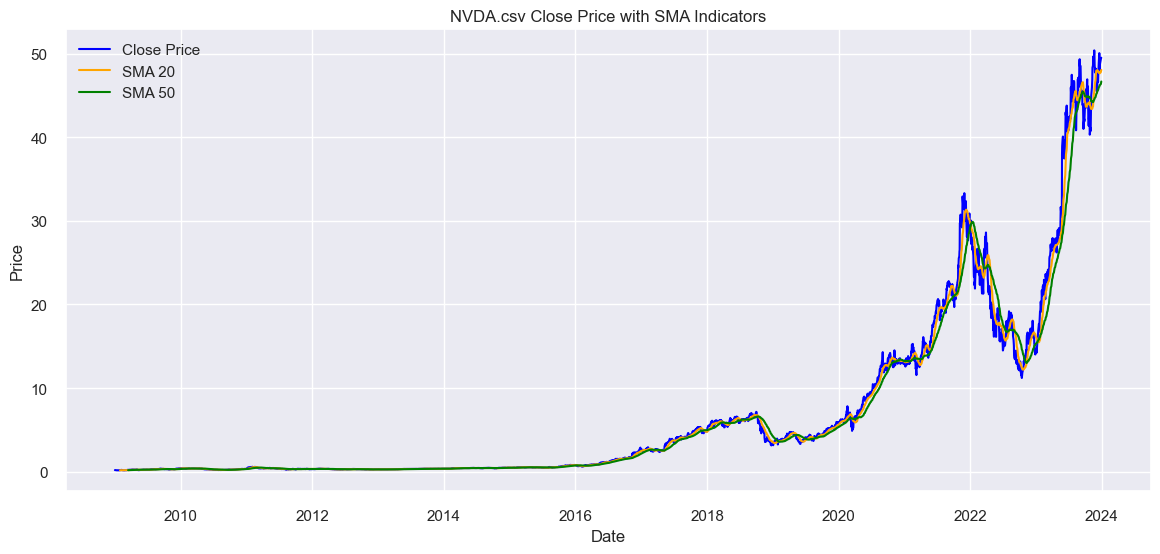

In [25]:
import matplotlib.pyplot as plt

for stock_name, df in dfs.items():
    plt.figure(figsize=(14,6))
    plt.plot(df['Close'], label='Close Price', color='blue')
    if 'SMA_20' in df.columns:
        plt.plot(df['SMA_20'], label='SMA 20', color='orange')
    if 'SMA_50' in df.columns:
        plt.plot(df['SMA_50'], label='SMA 50', color='green')
    plt.title(f'{stock_name} Close Price with SMA Indicators')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()


# Plot RSI

Visualizes the 14-day Relative Strength Index (RSI) with overbought and oversold thresholds.


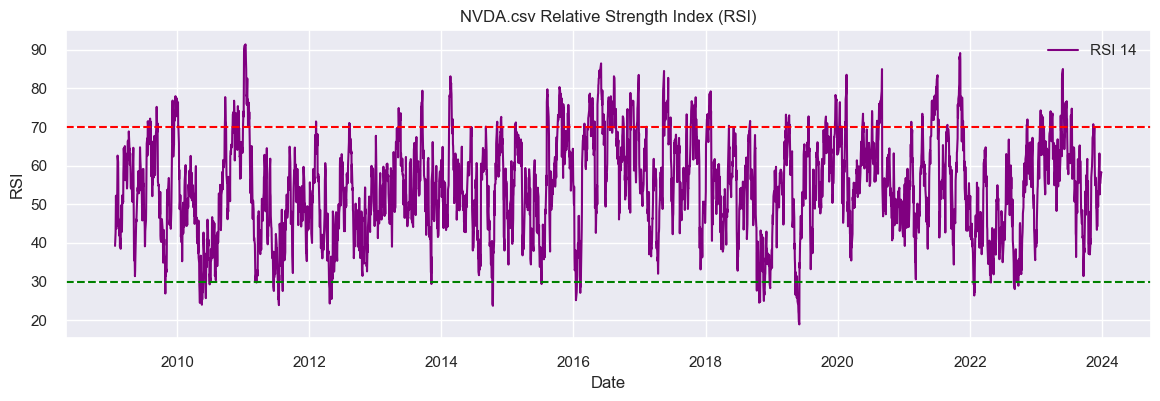

In [26]:
plt.figure(figsize=(14,4))
plt.plot(df['RSI_14'], label='RSI 14', color='purple')
plt.axhline(70, color='red', linestyle='--')  # Overbought
plt.axhline(30, color='green', linestyle='--') # Oversold
plt.title(f'{stock_name} Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

# Plot MACD

Visualizes MACD, MACD signal, and MACD histogram for the stock.


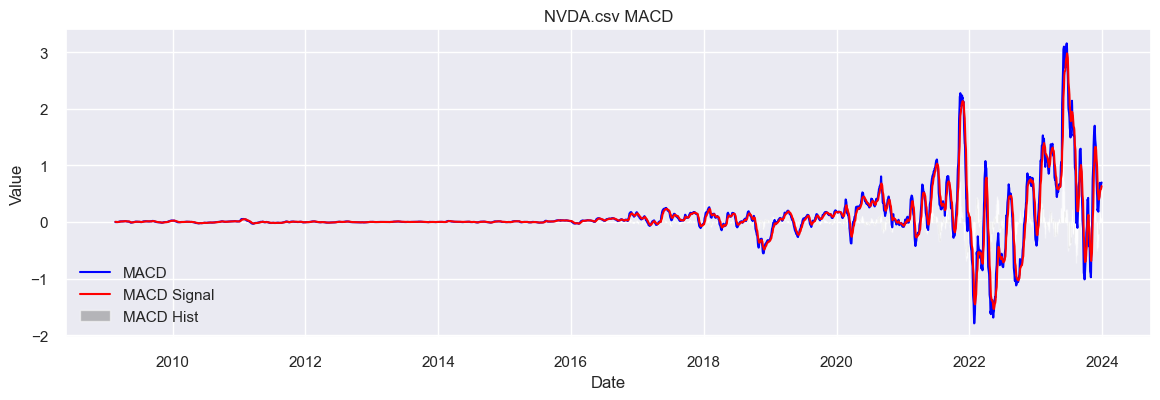

In [27]:

plt.figure(figsize=(14,4))
plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['MACD_signal'], label='MACD Signal', color='red')
plt.bar(df.index, df['MACD_hist'], label='MACD Hist', color='grey', alpha=0.5)
plt.title(f'{stock_name} MACD')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Plot Technical Indicators for All Stocks

Generates visualizations for each stock: Close price with SMAs, RSI, and MACD (if available).


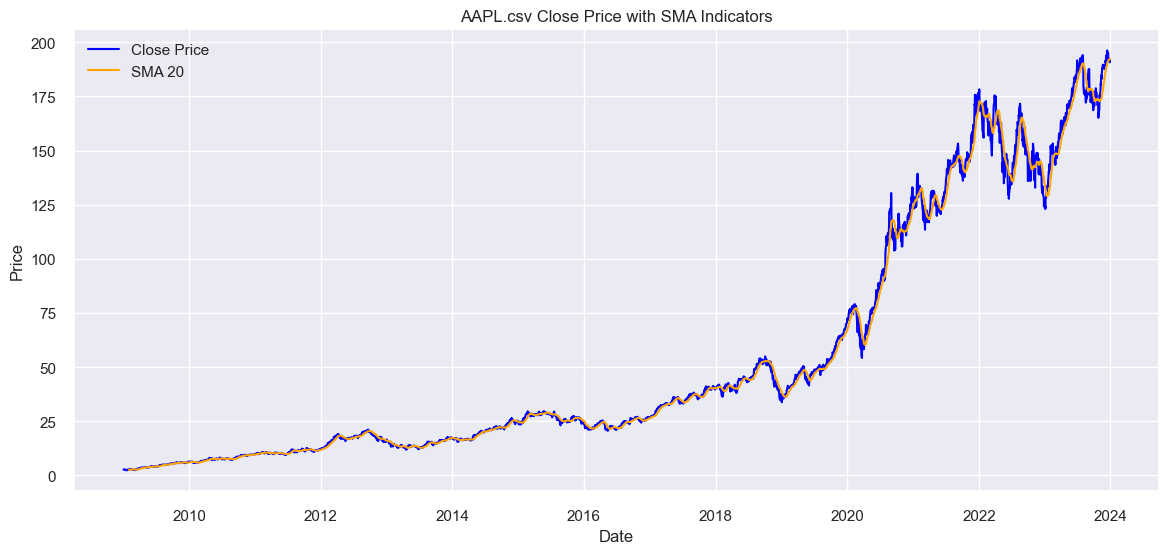

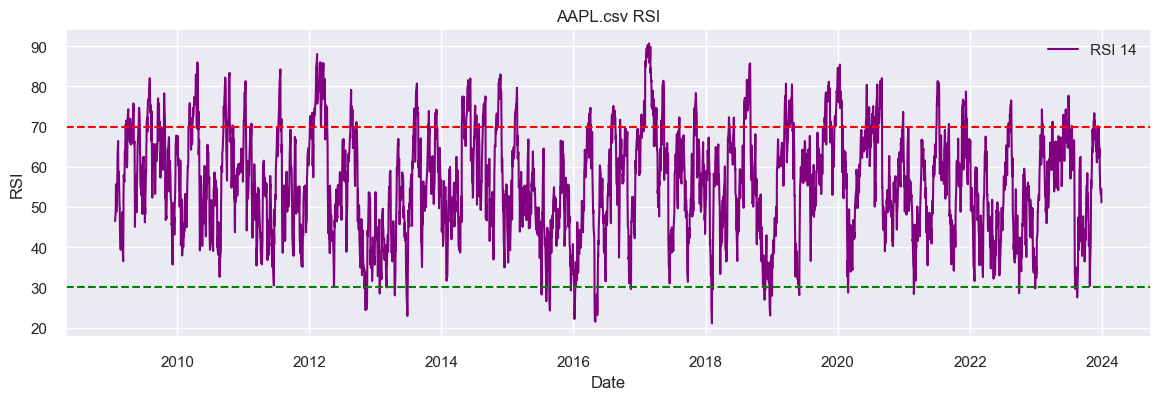

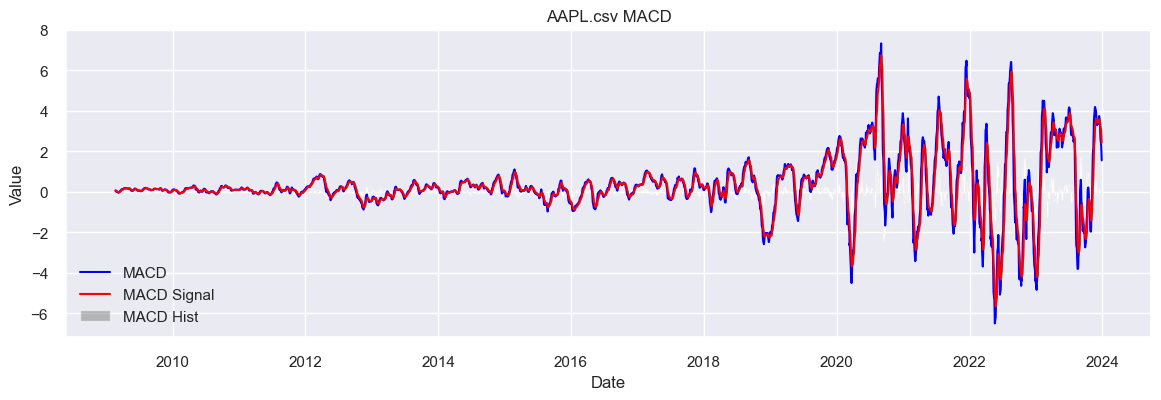

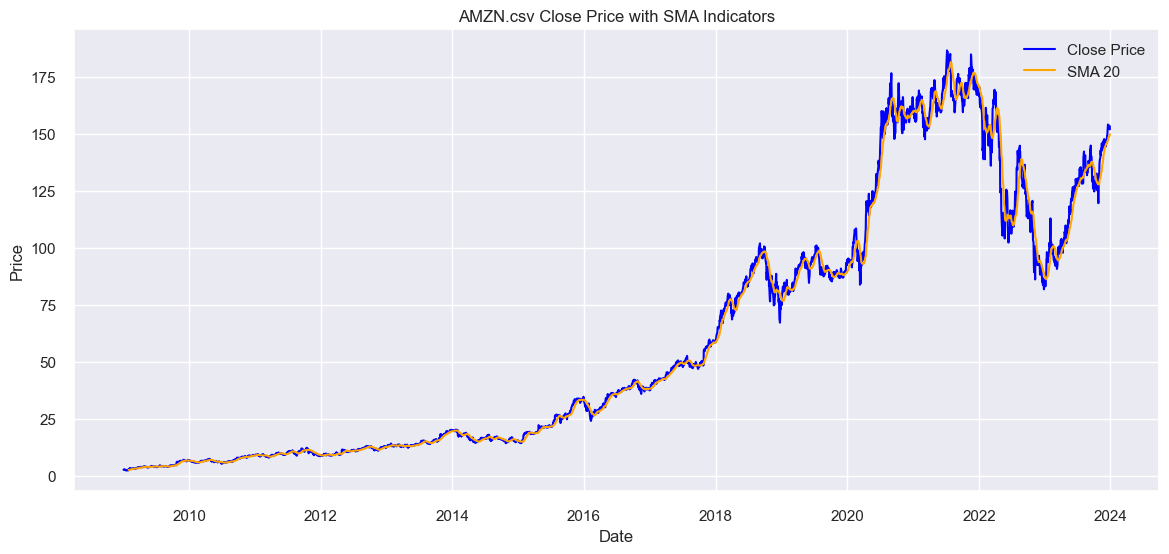

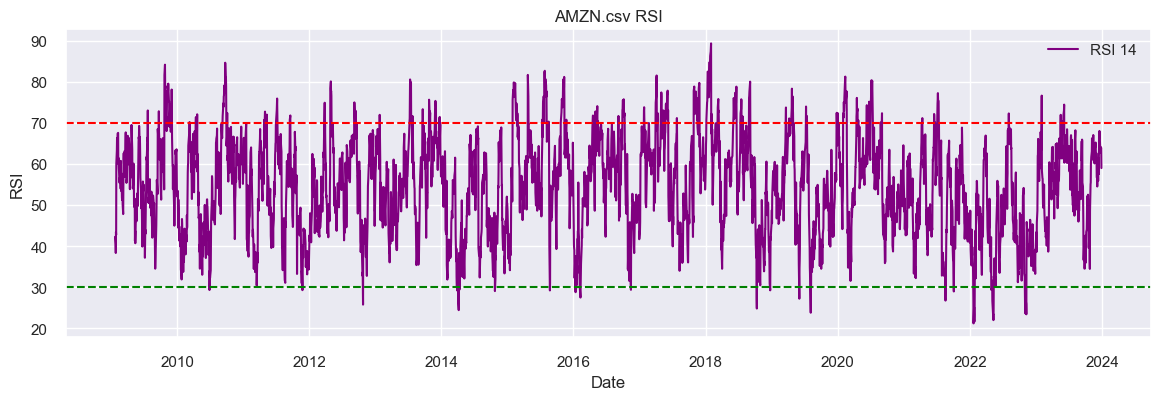

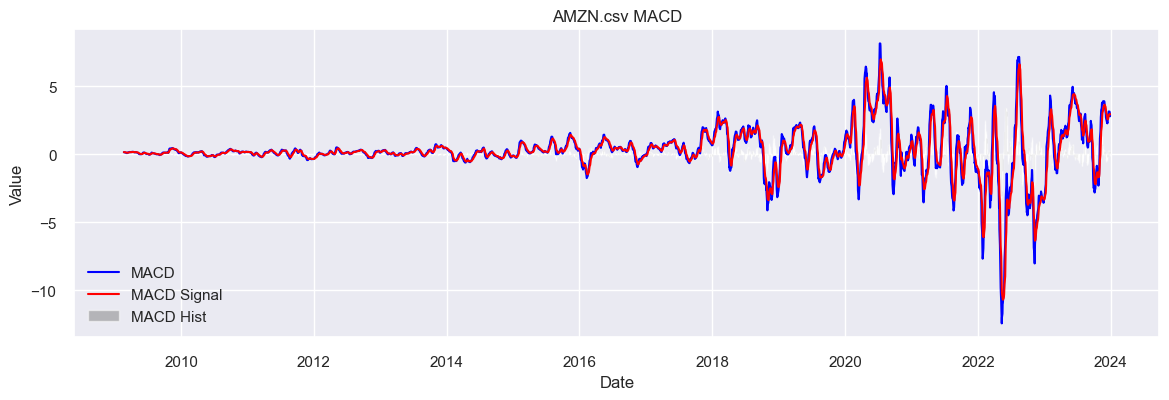

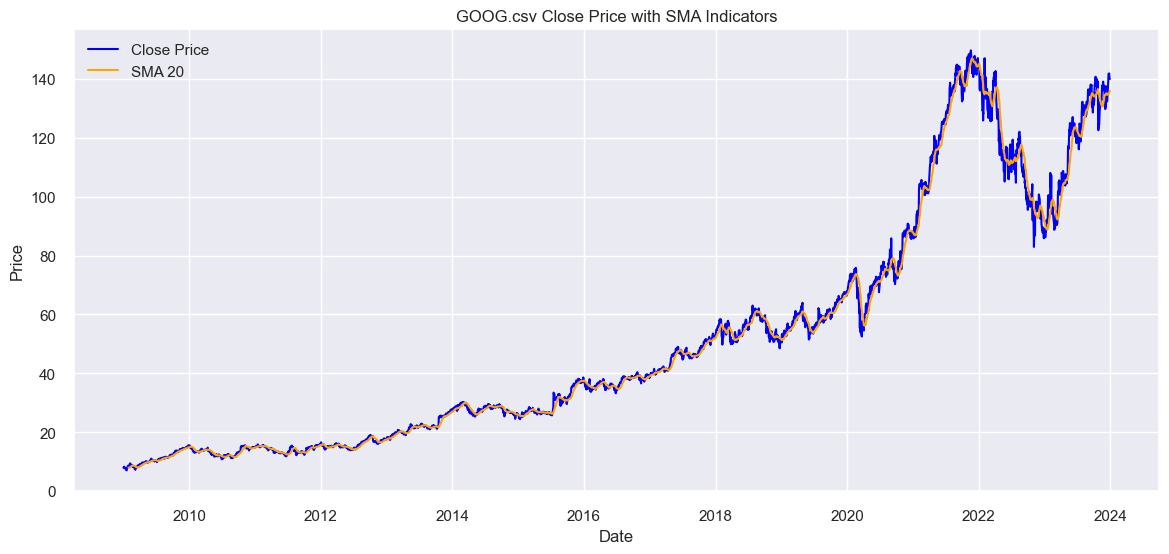

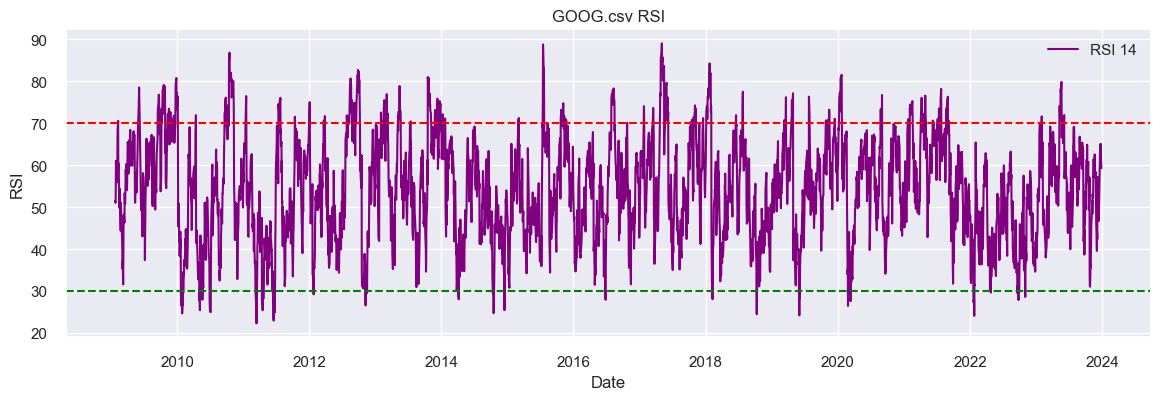

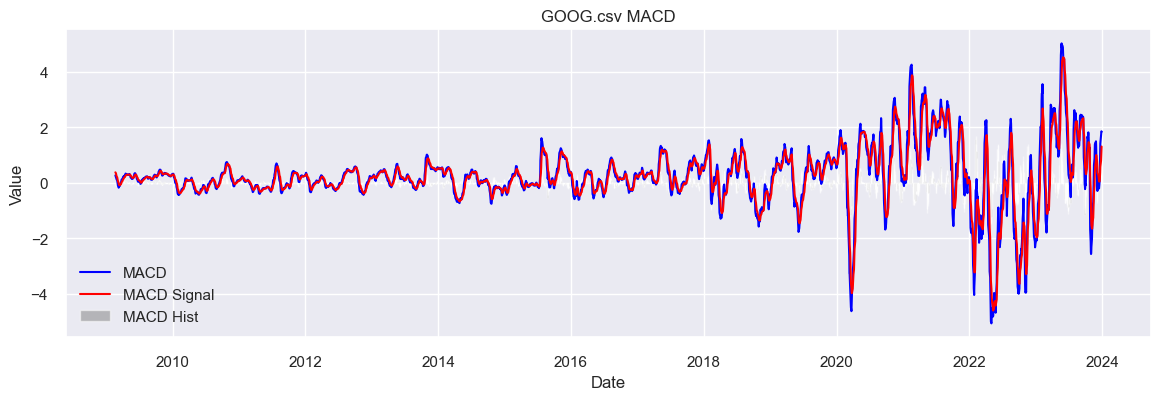

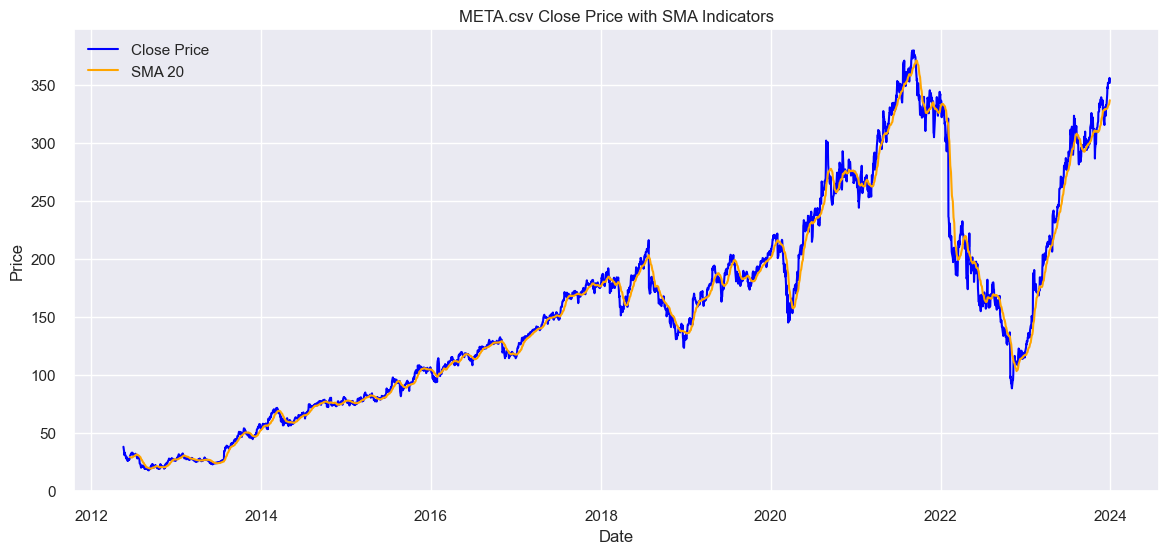

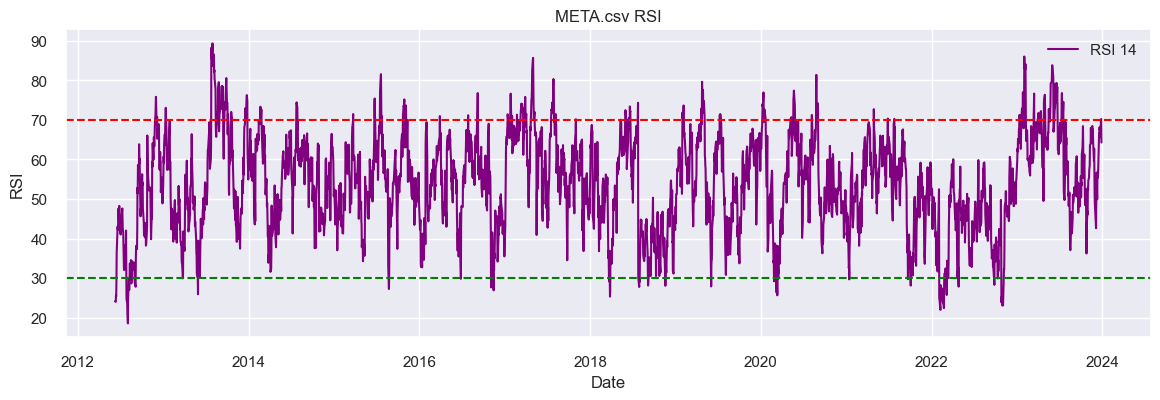

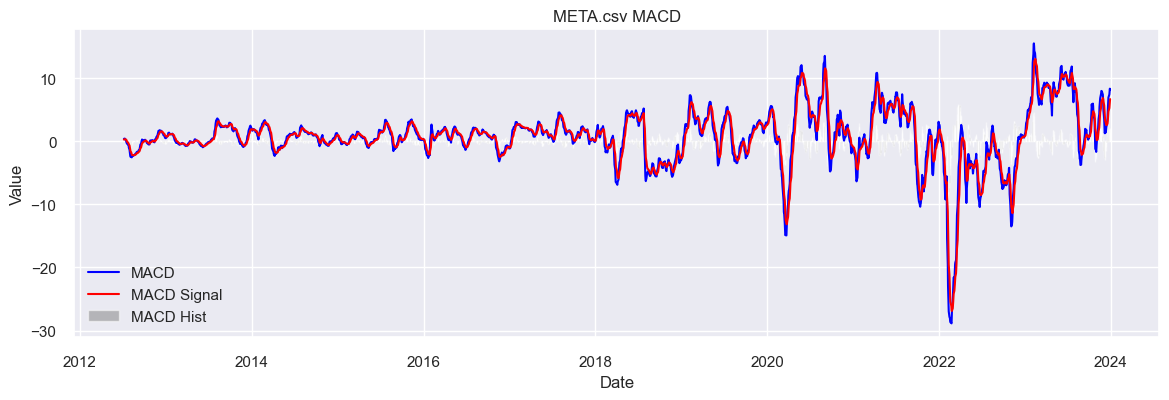

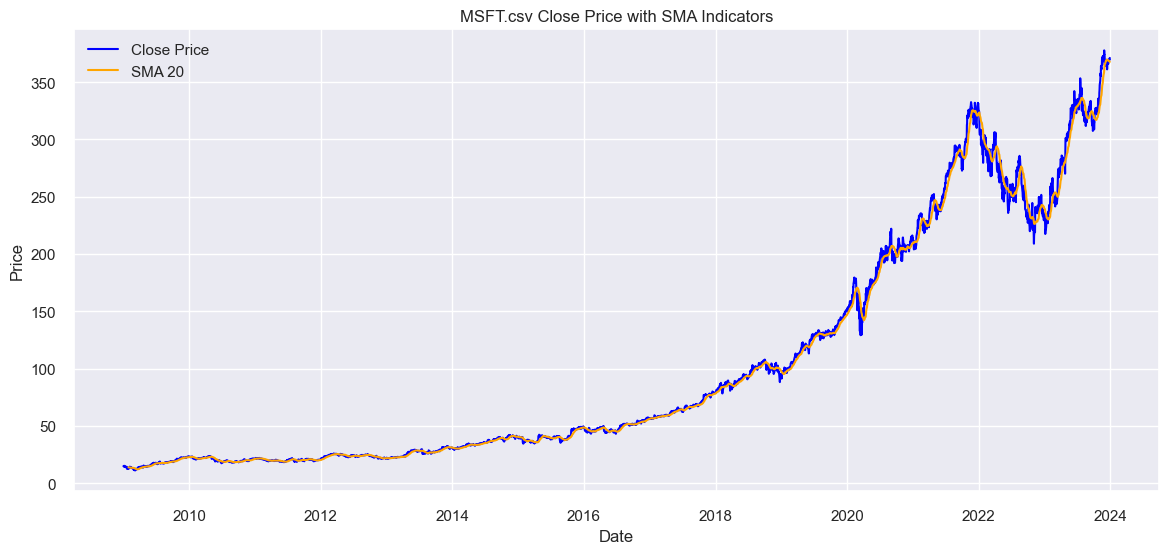

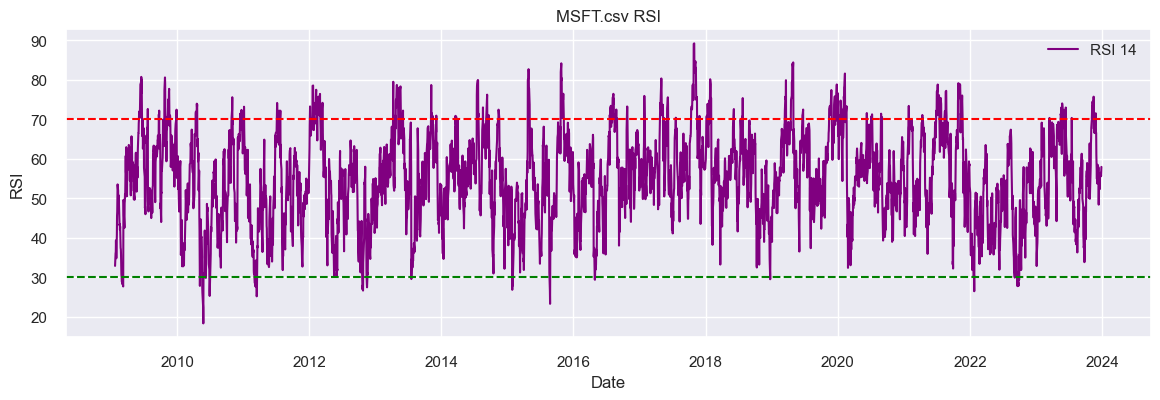

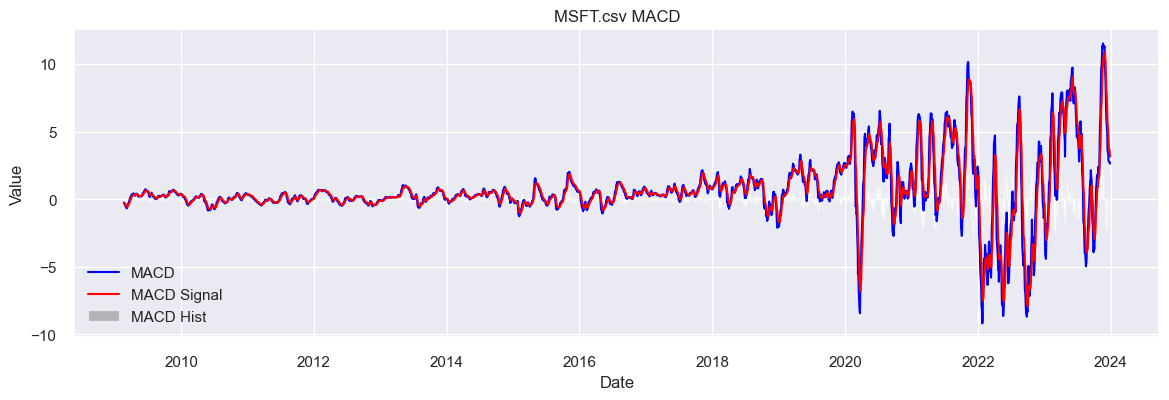

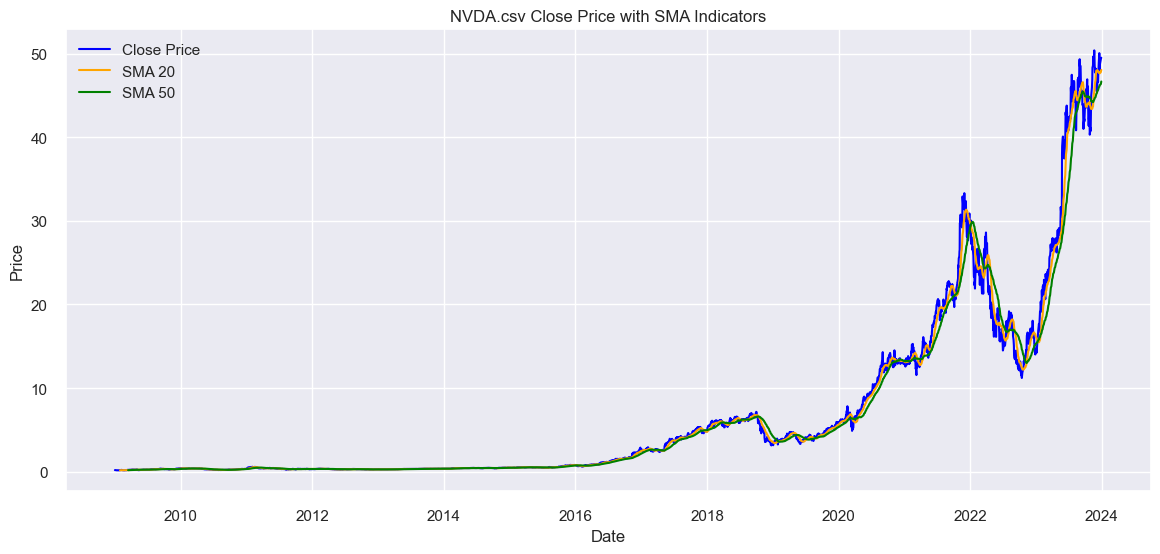

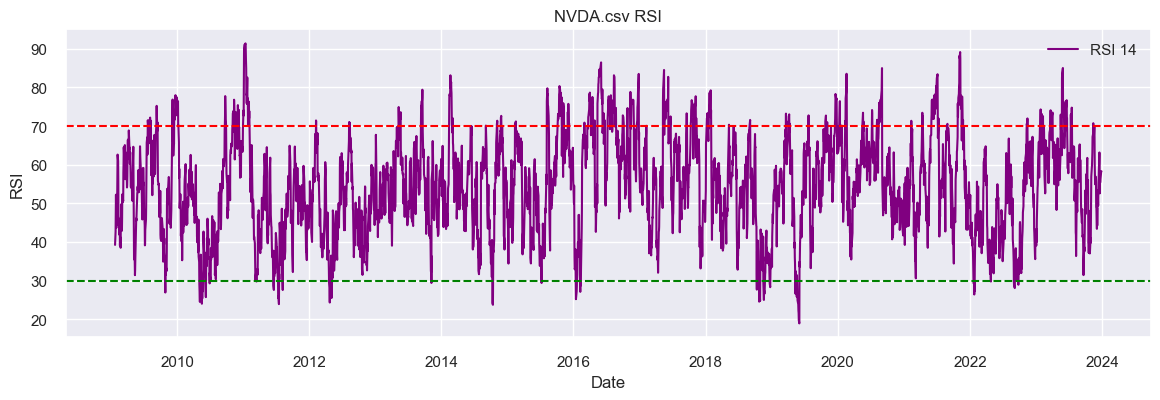

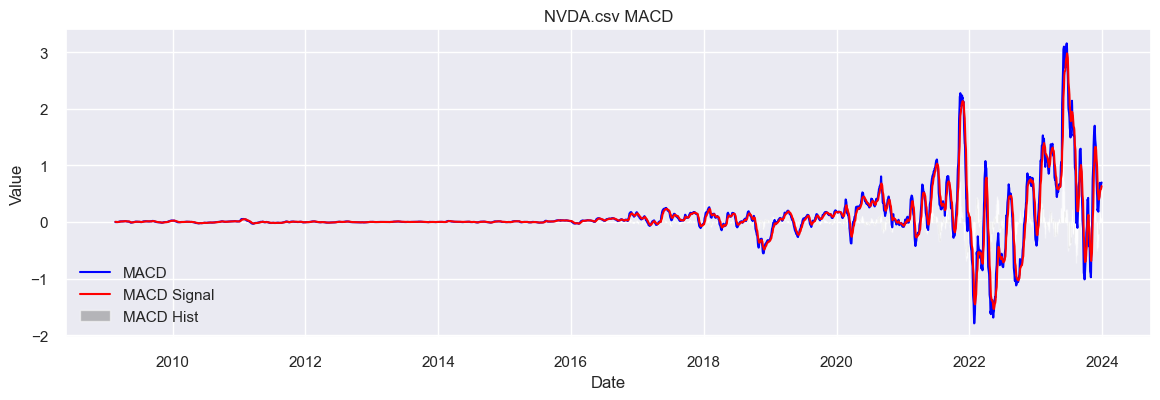

In [28]:
import matplotlib.pyplot as plt

for stock_name, df in dfs.items():
    plt.figure(figsize=(14,6))
    
    # Plot Close Price
    plt.plot(df['Close'], label='Close Price', color='blue')
    
    # Plot SMA indicators if they exist
    if 'SMA_20' in df.columns:
        plt.plot(df['SMA_20'], label='SMA 20', color='orange')
    if 'SMA_50' in df.columns:
        plt.plot(df['SMA_50'], label='SMA 50', color='green')
    
    plt.title(f'{stock_name} Close Price with SMA Indicators')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    
    # Plot RSI if it exists
    if 'RSI_14' in df.columns:
        plt.figure(figsize=(14,4))
        plt.plot(df['RSI_14'], label='RSI 14', color='purple')
        plt.axhline(70, color='red', linestyle='--')
        plt.axhline(30, color='green', linestyle='--')
        plt.title(f'{stock_name} RSI')
        plt.xlabel('Date')
        plt.ylabel('RSI')
        plt.legend()
        plt.show()
    
    # Plot MACD if it exists
    if 'MACD' in df.columns and 'MACD_signal' in df.columns and 'MACD_hist' in df.columns:
        plt.figure(figsize=(14,4))
        plt.plot(df['MACD'], label='MACD', color='blue')
        plt.plot(df['MACD_signal'], label='MACD Signal', color='red')
        plt.bar(df.index, df['MACD_hist'], label='MACD Hist', color='grey', alpha=0.5)
        plt.title(f'{stock_name} MACD')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.legend()
        plt.show()

# Close Price Correlation

Computes and prints correlations of all numeric columns with the Close price for each stock.


In [29]:
for stock_name, df in dfs.items():
    print(f"--- {stock_name} ---")
    
    # Only select numeric columns
    numeric_cols = df.select_dtypes(include='number')
    
    # Compute correlation matrix
    corr_matrix = numeric_cols.corr()
    
    # Focus on Close price correlations
    close_corr = corr_matrix['Close'].sort_values(ascending=False)
    print("Correlation with Close Price:\n", close_corr, "\n")

--- AAPL.csv ---
Correlation with Close Price:
 Close          1.000000
Low            0.999904
High           0.999899
Open           0.999790
BB_middle      0.999647
BB_lower       0.999392
BB_upper       0.999385
EMA_20         0.998732
SMA_20         0.998245
ATR_14         0.909933
MACD_signal    0.267556
MACD           0.255701
MACD_hist      0.014989
RSI_14        -0.021487
Volume        -0.549822
Name: Close, dtype: float64 

--- AMZN.csv ---
Correlation with Close Price:
 Close          1.000000
Low            0.999863
High           0.999856
Open           0.999693
BB_middle      0.999430
BB_upper       0.998973
BB_lower       0.998960
EMA_20         0.998019
SMA_20         0.997234
ATR_14         0.893355
MACD_signal    0.135028
MACD           0.131353
MACD_hist      0.016657
RSI_14        -0.051463
Volume        -0.217365
Name: Close, dtype: float64 

--- GOOG.csv ---
Correlation with Close Price:
 Close          1.000000
Low            0.999883
High           0.999873
Open

# Close Price vs Indicators

Creates scatter plots of Close price against SMA 50 and RSI 14 for each stock.


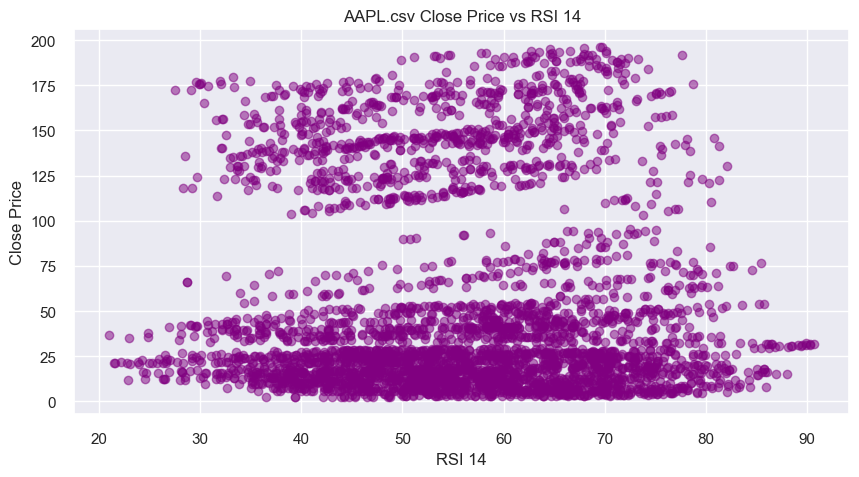

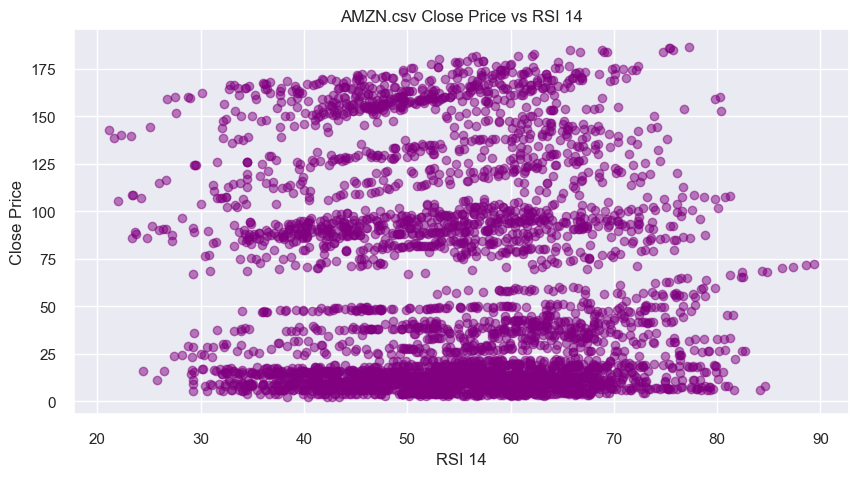

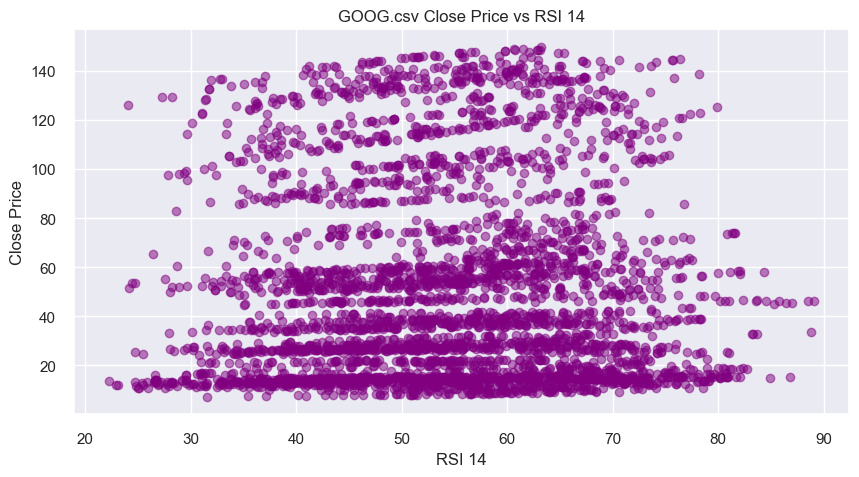

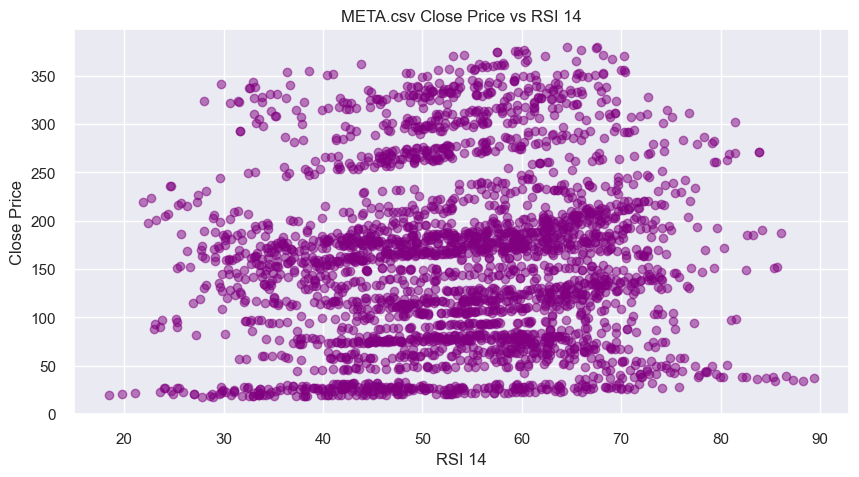

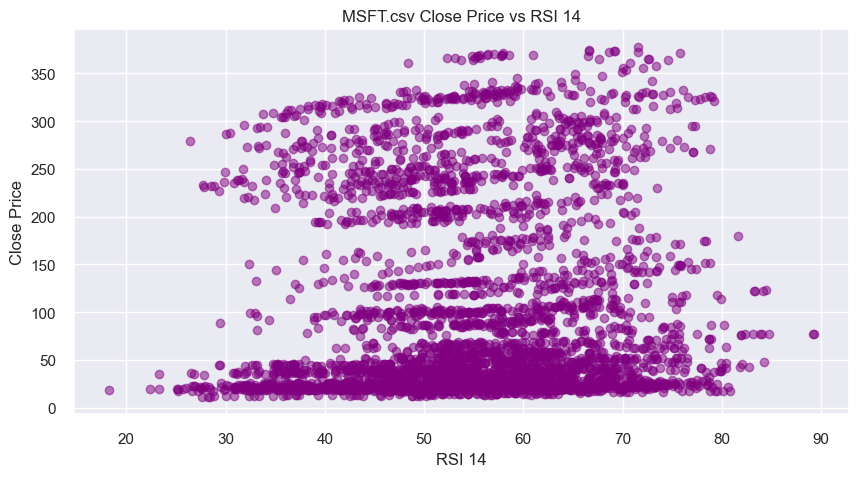

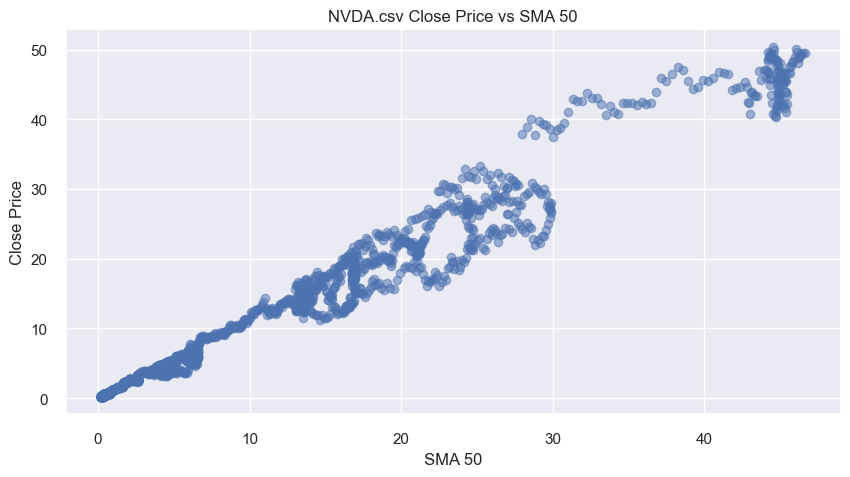

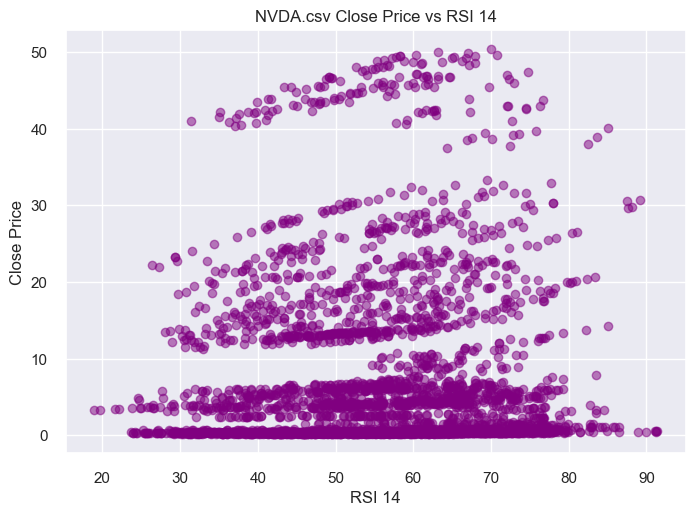

In [30]:
for stock_name, df in dfs.items():
    plt.figure(figsize=(10,5))
    
    if 'SMA_50' in df.columns:
        plt.scatter(df['SMA_50'], df['Close'], alpha=0.5)
        plt.title(f'{stock_name} Close Price vs SMA 50')
        plt.xlabel('SMA 50')
        plt.ylabel('Close Price')
        plt.show()
    
    if 'RSI_14' in df.columns:
        plt.scatter(df['RSI_14'], df['Close'], alpha=0.5, color='purple')
        plt.title(f'{stock_name} Close Price vs RSI 14')
        plt.xlabel('RSI 14')
        plt.ylabel('Close Price')
        plt.show()

# Summary Statistics for Indicators

Prints descriptive statistics for selected technical indicators (SMA 20, SMA 50, RSI 14, MACD) for each stock.


In [31]:
for stock_name, df in dfs.items():
    print(f"--- {stock_name} ---")
    
    # List of indicators you want
    indicators = ['SMA_20', 'SMA_50', 'RSI_14', 'MACD']
    
    # Only keep columns that exist in this df
    existing_indicators = [col for col in indicators if col in df.columns]
    
    if existing_indicators:
        print(df[existing_indicators].describe(), "\n")
    else:
        print("No indicators calculated for this stock.\n")

--- AAPL.csv ---
            SMA_20       RSI_14         MACD
count  3755.000000  3760.000000  3741.000000
mean     53.619188    56.016263     0.349132
std      54.644055    12.932862     1.477349
min       2.661195    21.030028    -6.488947
25%      14.930003    46.478750    -0.084944
50%      26.851083    56.032443     0.160637
75%      73.403381    65.488870     0.663745
max     192.490633    90.695350     7.332299 

--- AMZN.csv ---
            SMA_20       RSI_14         MACD
count  3755.000000  3760.000000  3741.000000
mean     59.318428    54.565463     0.269490
std      54.702612    11.701488     1.783870
min       2.615850    21.168752   -12.431501
25%      12.178500    45.821217    -0.136856
50%      36.233550    55.114769     0.155371
75%      96.479312    63.011281     0.738014
max     181.521350    89.384094     8.134473 

--- GOOG.csv ---
            SMA_20       RSI_14         MACD
count  3755.000000  3760.000000  3741.000000
mean     50.667995    54.332977     0.238067


# Generate RSI Trading Signals

Creates buy/sell signals based on RSI:

* RSI > 70 → Sell (-1)
* RSI < 30 → Buy (1)
  Prints signal counts for each stock.


In [32]:

for stock_name, df in dfs.items():
    df['RSI_signal'] = 0
    if 'RSI_14' in df.columns:
        df.loc[df['RSI_14'] > 70, 'RSI_signal'] = -1  # Sell
        df.loc[df['RSI_14'] < 30, 'RSI_signal'] = 1   # Buy
    print(f"{stock_name} RSI signals:\n", df['RSI_signal'].value_counts(), "\n")

AAPL.csv RSI signals:
 RSI_signal
 0    3132
-1     574
 1      68
Name: count, dtype: int64 

AMZN.csv RSI signals:
 RSI_signal
 0    3387
-1     339
 1      48
Name: count, dtype: int64 

GOOG.csv RSI signals:
 RSI_signal
 0    3319
-1     387
 1      68
Name: count, dtype: int64 

META.csv RSI signals:
 RSI_signal
 0    2612
-1     235
 1      76
Name: count, dtype: int64 

MSFT.csv RSI signals:
 RSI_signal
 0    3367
-1     363
 1      44
Name: count, dtype: int64 

NVDA.csv RSI signals:
 RSI_signal
 0    3253
-1     447
 1      74
Name: count, dtype: int64 



# Full Correlation Matrix

Computes and prints the correlation matrix of all numeric columns for each stock.


In [33]:
for stock_name, df in dfs.items():
    print(f"--- {stock_name} ---")
    
    # Only keep numeric columns
    numeric_cols = df.select_dtypes(include='number').columns
    corr_matrix = df[numeric_cols].corr()
    
    print(corr_matrix, "\n")

--- AAPL.csv ---
                Close      High       Low      Open    Volume    SMA_20  \
Close        1.000000  0.999899  0.999904  0.999790 -0.549822  0.998245   
High         0.999899  1.000000  0.999875  0.999916 -0.548758  0.998474   
Low          0.999904  0.999875  1.000000  0.999899 -0.550777  0.998213   
Open         0.999790  0.999916  0.999899  1.000000 -0.549563  0.998414   
Volume      -0.549822 -0.548758 -0.550777 -0.549563  1.000000 -0.549393   
SMA_20       0.998245  0.998474  0.998213  0.998414 -0.549393  1.000000   
EMA_20       0.998732  0.998930  0.998704  0.998871 -0.549933  0.999908   
RSI_14      -0.021487 -0.025103 -0.021487 -0.025034 -0.048418 -0.058480   
MACD         0.255701  0.253562  0.257591  0.255422 -0.144189  0.213532   
MACD_signal  0.267556  0.266389  0.269696  0.268558 -0.142715  0.238947   
MACD_hist    0.014989  0.011576  0.014603  0.011004 -0.033479 -0.035072   
BB_upper     0.999385  0.999577  0.999326  0.999488 -0.547199  0.998901   
BB_middl

# Correlation Heatmaps

Generates heatmaps showing correlations among numeric columns for each stock using Seaborn.


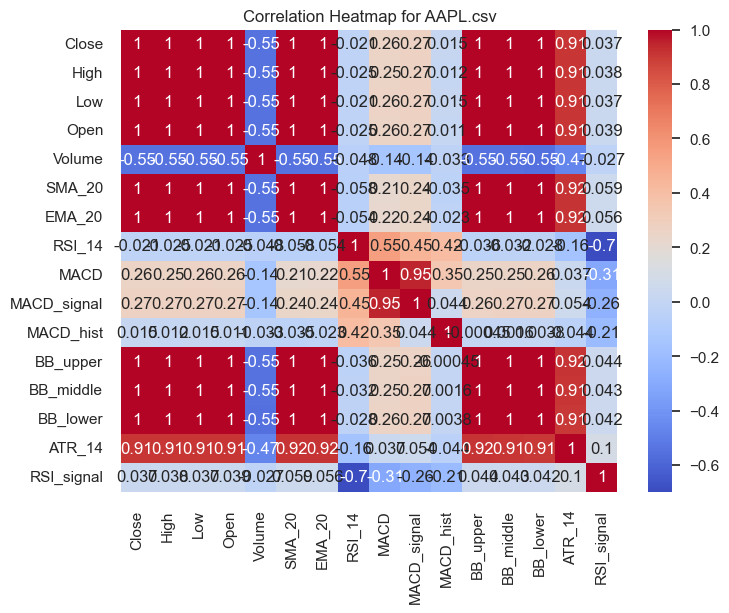

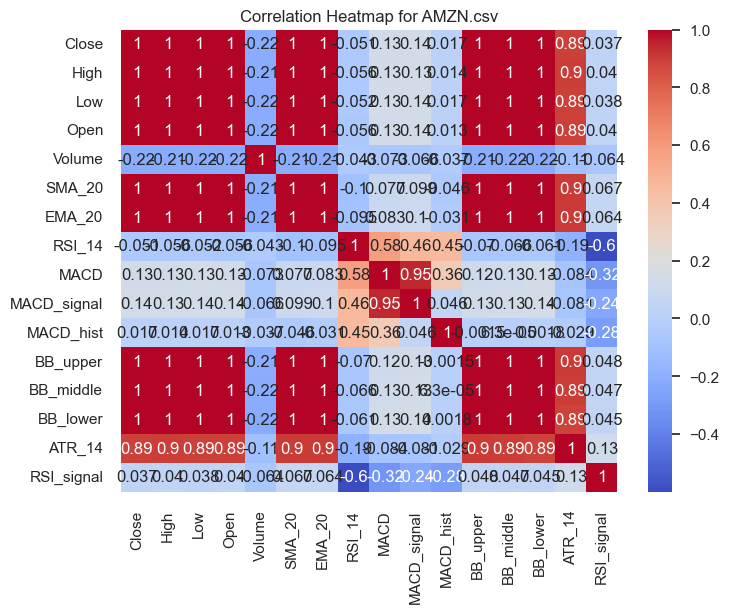

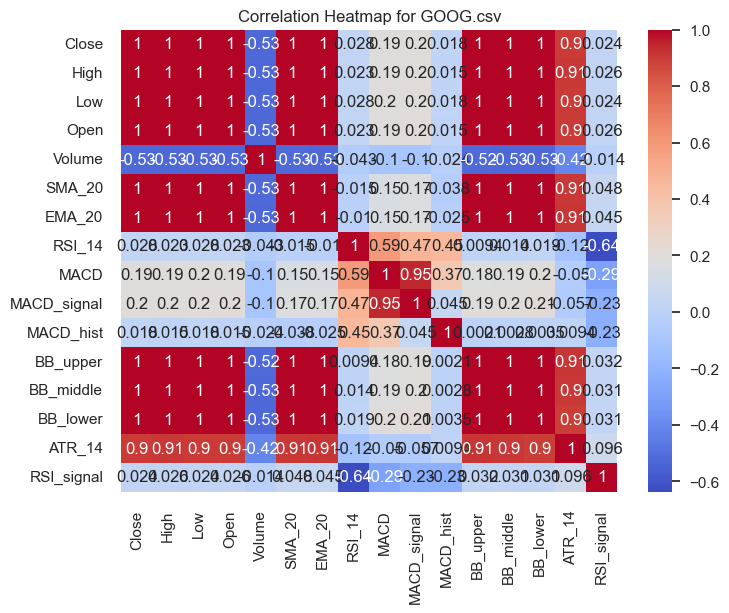

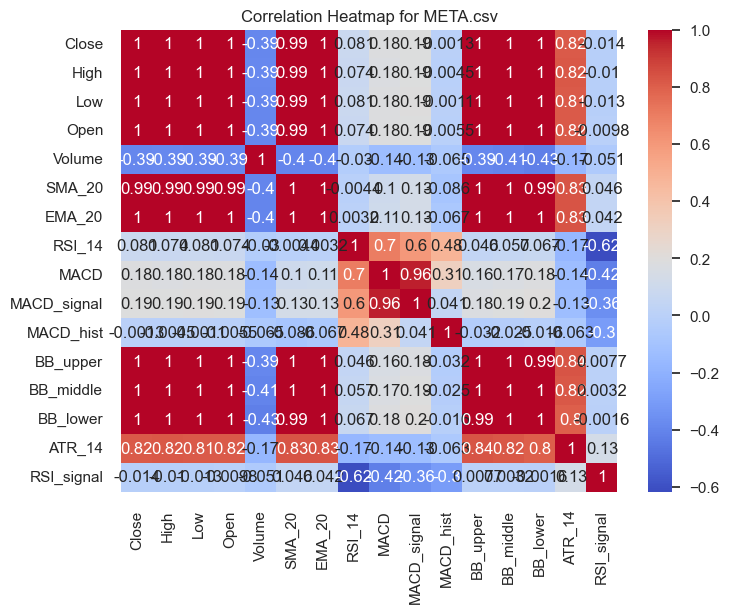

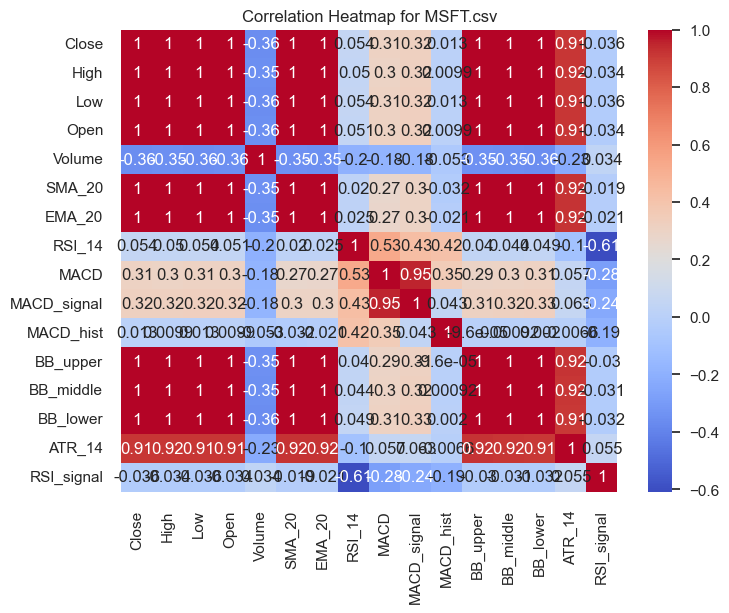

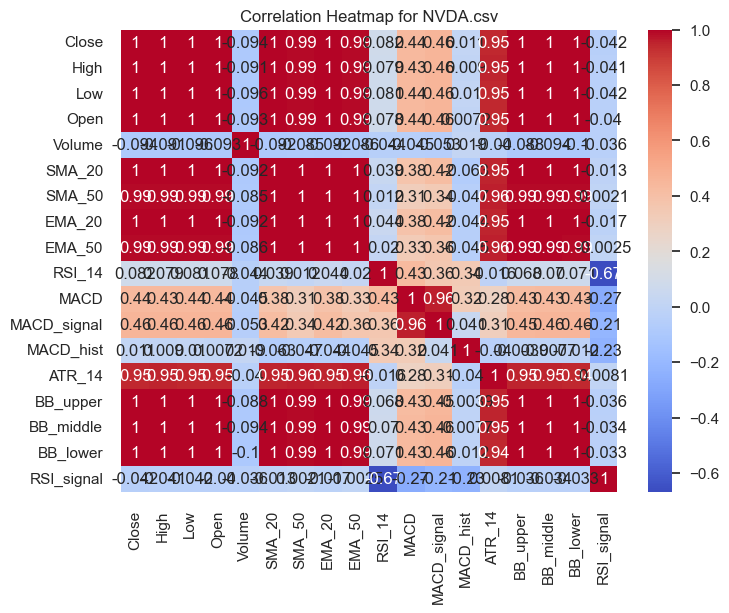

In [34]:

import seaborn as sns
import matplotlib.pyplot as plt

for stock_name, df in dfs.items():
    numeric_cols = df.select_dtypes(include='number').columns
    if len(numeric_cols) > 1:
        plt.figure(figsize=(8,6))
        sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
        plt.title(f'Correlation Heatmap for {stock_name}')
        plt.show()

# Task 2: Technical Indicator Insights

## Overview

This analysis explores the relationships and predictive potential of key technical indicators (SMA, MACD, RSI) across six stocks.

## Key Insights

* **SMA Trends:**

  * SMA_20 and SMA_50 generally show strong positive correlation, indicating consistent momentum patterns.
  * SMA_20 correlates moderately to strongly with Close prices, useful for short-term trend detection.

* **Momentum Indicators:**

  * RSI_14 and MACD show moderate negative correlation, highlighting potential overbought/oversold conditions.
  * MACD effectiveness varies by stock; stronger for stable stocks (AAPL, MSFT), weaker for volatile stocks (NVDA, META).

* **Stock-specific Observations:**

  * Stable stocks: SMA indicators reliably reflect trends.
  * Volatile stocks: SMA correlations are lower; adaptive strategies are needed.

## Recommendations

* **Trend-Following:**

  * Use SMA_20/SMA_50 crossovers to detect trend shifts.

* **Momentum & Reversal:**

  * Combine MACD and RSI with SMAs to spot momentum changes or reversals.
  * RSI can flag overbought/oversold conditions to refine entry/exit points.

* **Combined Approach:**

  * Integrate multiple indicators for a robust trading strategy rather than relying on a single metric.

## Future Work

* Combine Task-1 sentiment analysis with technical indicators for predictive modeling.
* Explore additional indicators like Bollinger Bands or stochastic oscillators.
